Player stats analysis

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [22]:

file_path = "../datasets/Batsmen_Stats.csv"
df = pd.read_csv(file_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  150 non-null    object 
 1   Span    150 non-null    object 
 2   Mat     150 non-null    int64  
 3   Inns    150 non-null    int64  
 4   NO      150 non-null    object 
 5   Runs    150 non-null    int64  
 6   HS      150 non-null    object 
 7   Ave     150 non-null    float64
 8   BF      150 non-null    int64  
 9   SR      150 non-null    float64
 10  100     150 non-null    object 
 11  50      150 non-null    object 
 12  0       150 non-null    object 
 13  4s      150 non-null    int64  
 14  6s      150 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 17.7+ KB


In [23]:

df["HS"] = df["HS"].str.replace("*", "", regex=False).astype(float)
df["100"] = pd.to_numeric(df["100"], errors="coerce").fillna(0)
df["50"] = pd.to_numeric(df["50"], errors="coerce").fillna(0)
df["0"] = pd.to_numeric(df["0"], errors="coerce").fillna(0)

C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\98115938.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Consistency Score", y="Player", data=top_consistent, palette="viridis")


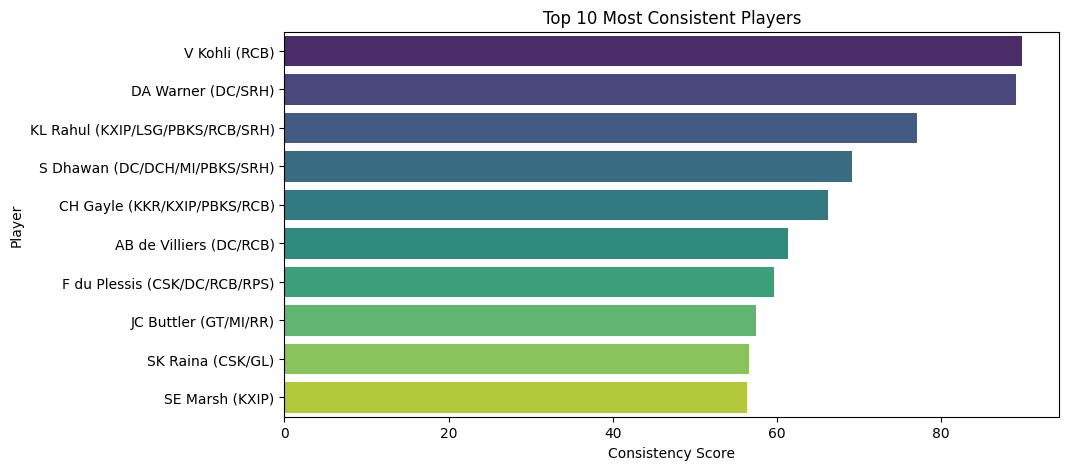

In [24]:

df["Consistency Score"] = (df["Runs"] / df["Inns"]) + (2 * df["100"]) + (1 * df["50"]) - (1.5 * df["0"])


top_consistent = df.nlargest(10, "Consistency Score")

plt.figure(figsize=(10, 5))
sns.barplot(x="Consistency Score", y="Player", data=top_consistent, palette="viridis")
plt.title("Top 10 Most Consistent Players")
plt.xlabel("Consistency Score")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\2993759461.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Impact Score", y="Player", data=top_impact, palette="coolwarm")


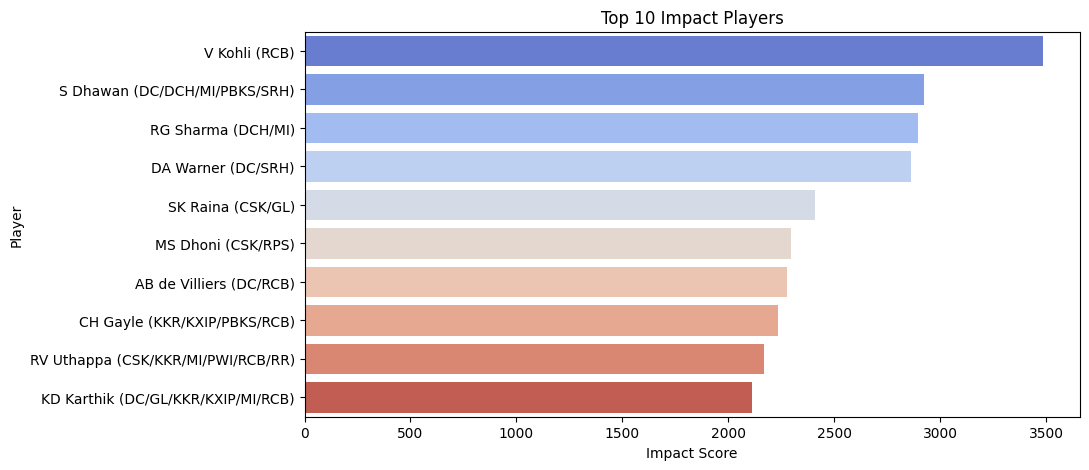

In [25]:



df["Impact Score"] = (df["Runs"] * 0.4) + (df["SR"] * 0.3) + (df["4s"] * 0.15) + (df["6s"] * 0.4) + ((df["4s"] + df["6s"]) / df["BF"] * 10)

top_impact = df.nlargest(10, "Impact Score")


plt.figure(figsize=(10, 5))
sns.barplot(x="Impact Score", y="Player", data=top_impact, palette="coolwarm")
plt.title("Top 10 Impact Players")
plt.xlabel("Impact Score")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\653490881.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Conversion Rate", y="Player", data=top_conversion, palette="Blues_r")


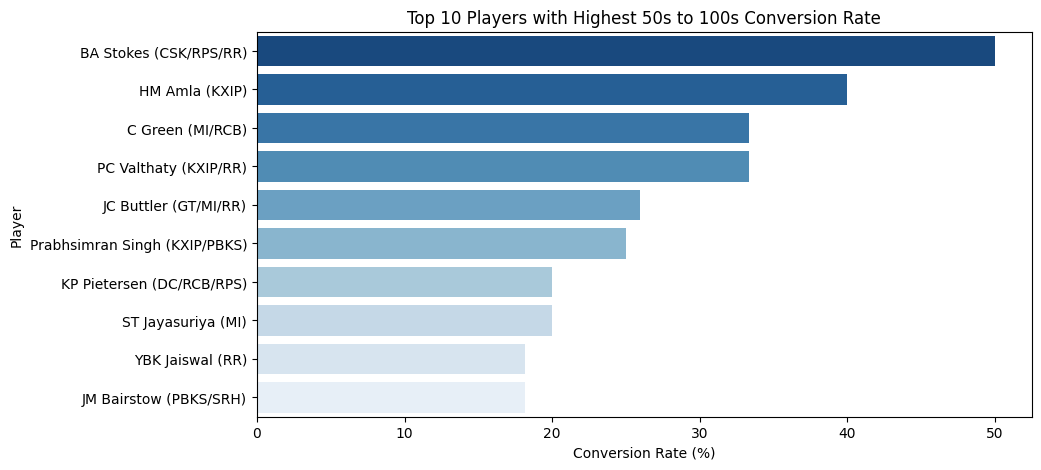

In [26]:

df["Conversion Rate"] = (df["100"] / (df["100"] + df["50"])) * 100
df["Conversion Rate"] = df["Conversion Rate"].fillna(0)  

top_conversion = df.nlargest(10, "Conversion Rate")

plt.figure(figsize=(10, 5))
sns.barplot(x="Conversion Rate", y="Player", data=top_conversion, palette="Blues_r")
plt.title("Top 10 Players with Highest 50s to 100s Conversion Rate")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\1260710775.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balls per Boundary", y="Player", data=top_boundary_hitters, palette="coolwarm_r")


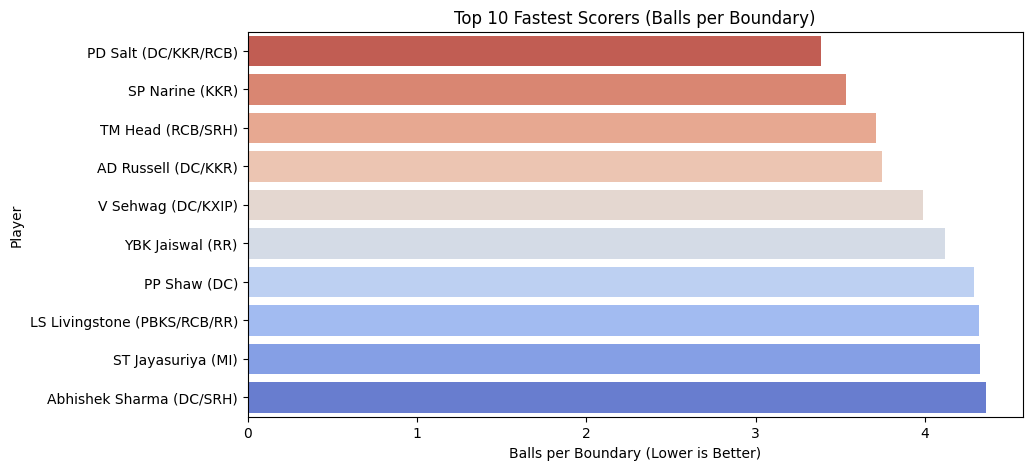

In [27]:

df["Balls per Boundary"] = df["BF"] / (df["4s"] + df["6s"]).replace(0, 1)  


df_filtered = df[df["BF"] >= 50]

top_boundary_hitters = df_filtered.nsmallest(10, "Balls per Boundary")


plt.figure(figsize=(10, 5))
sns.barplot(x="Balls per Boundary", y="Player", data=top_boundary_hitters, palette="coolwarm_r")
plt.title("Top 10 Fastest Scorers (Balls per Boundary)")
plt.xlabel("Balls per Boundary (Lower is Better)")
plt.ylabel("Player")
plt.show()

C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\530387255.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Impact Score", y="Player", data=top_big_innings_players, palette="plasma")


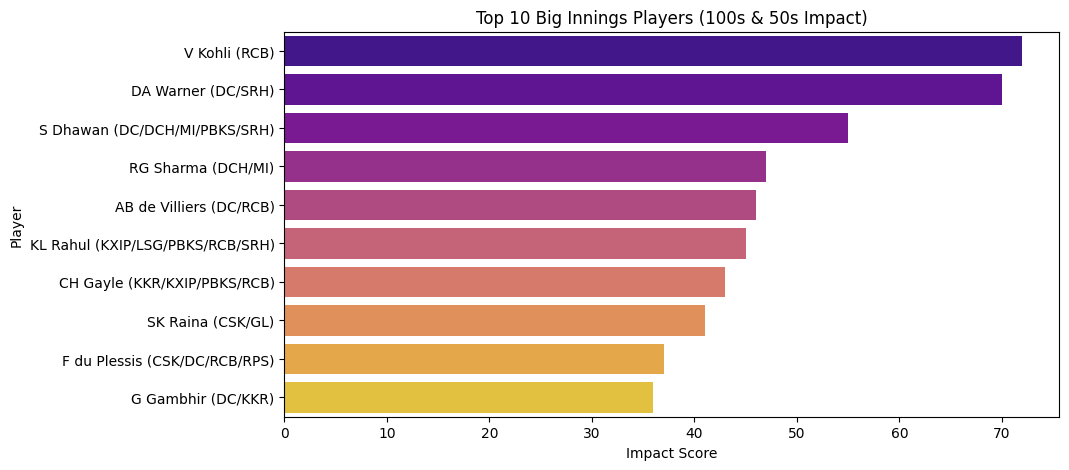

In [28]:

df["100"] = pd.to_numeric(df["100"], errors="coerce")
df["50"] = pd.to_numeric(df["50"], errors="coerce")

df["Impact Score"] = (df["100"] * 2) + (df["50"] * 1)


top_big_innings_players = df.nlargest(10, "Impact Score")

plt.figure(figsize=(10, 5))
sns.barplot(x="Impact Score", y="Player", data=top_big_innings_players, palette="plasma")
plt.title("Top 10 Big Innings Players (100s & 50s Impact)")
plt.xlabel("Impact Score")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\3259875419.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Big-Hitting Index"].fillna(0, inplace=True)
C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\3259875419.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Big-Hitting Index", y="Player", data=top_big_hitters, palette="Reds")


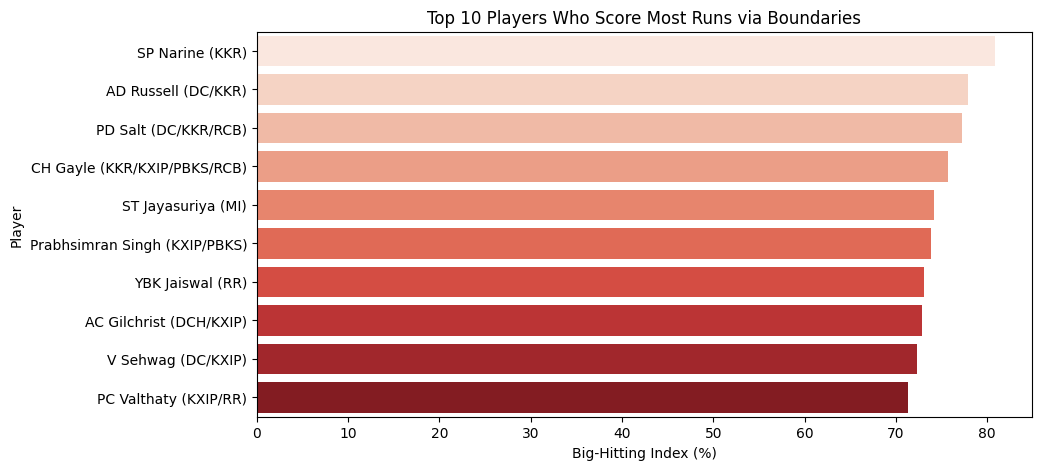

In [29]:

df["Big-Hitting Index"] = ((df["4s"] * 4) + (df["6s"] * 6)) / df["Runs"] * 100
df["Big-Hitting Index"].fillna(0, inplace=True)

top_big_hitters = df.nlargest(10, "Big-Hitting Index")


plt.figure(figsize=(10, 5))
sns.barplot(x="Big-Hitting Index", y="Player", data=top_big_hitters, palette="Reds")
plt.title("Top 10 Players Who Score Most Runs via Boundaries")
plt.xlabel("Big-Hitting Index (%)")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\2775465057.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="SSR", y="Player", data=top_smart_scorers, palette="Greens")


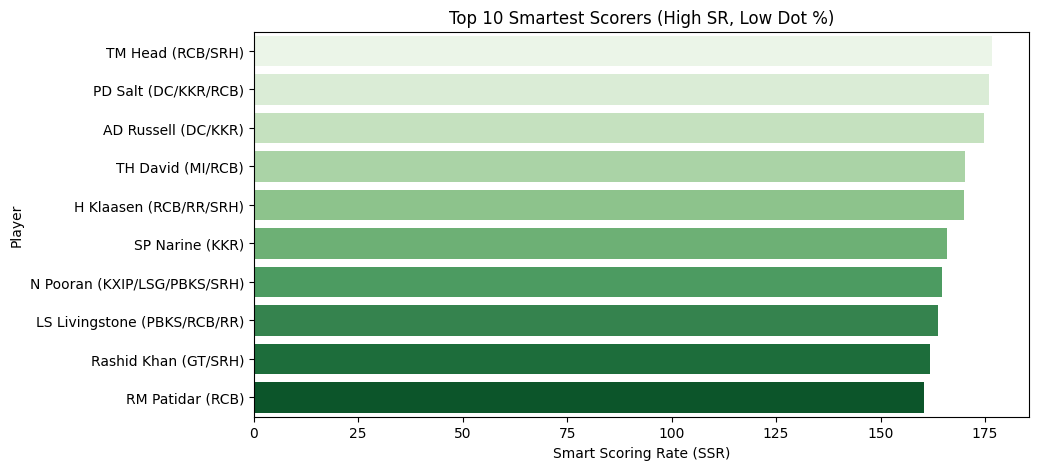

In [30]:

df = df[df["BF"] > 0]

df["Dot Ball %"] = ((df["BF"] - ((df["4s"] + df["6s"]) * 1) - (df["Runs"] / 1)) / df["BF"]) * 100


df["Dot Ball %"] = df["Dot Ball %"].clip(lower=0)  

df["SSR"] = df["SR"] * (1 - (df["Dot Ball %"] / 100))

top_smart_scorers = df.nlargest(10, "SSR")


plt.figure(figsize=(10, 5))
sns.barplot(x="SSR", y="Player", data=top_smart_scorers, palette="Greens")
plt.title("Top 10 Smartest Scorers (High SR, Low Dot %)")
plt.xlabel("Smart Scoring Rate (SSR)")
plt.ylabel("Player")
plt.show()

Bowlers Stats Analysis

In [31]:
df1= pd.read_csv("../datasets/Bowlers_Stats.csv")


df1.replace("-", "0", inplace=True)


numeric_cols = ["Mat", "Inns", "Balls", "Overs", "Mdns", "Runs", "Wkts", "Ave", "Econ", "SR", "4W", "5W"]
df1[numeric_cols] = df1[numeric_cols].apply(pd.to_numeric, errors='coerce')


df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  100 non-null    object 
 1   Span    100 non-null    object 
 2   Mat     100 non-null    int64  
 3   Inns    100 non-null    int64  
 4   Balls   100 non-null    int64  
 5   Overs   100 non-null    float64
 6   Mdns    100 non-null    int64  
 7   Runs    100 non-null    int64  
 8   Wkts    100 non-null    int64  
 9   BBI     100 non-null    object 
 10  Ave     100 non-null    float64
 11  Econ    100 non-null    float64
 12  SR      100 non-null    float64
 13  4W      100 non-null    int64  
 14  5W      100 non-null    int64  
dtypes: float64(4), int64(8), object(3)
memory usage: 11.8+ KB


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\570816977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Wkts", y="Player", data=top_wicket_takers, palette="viridis")


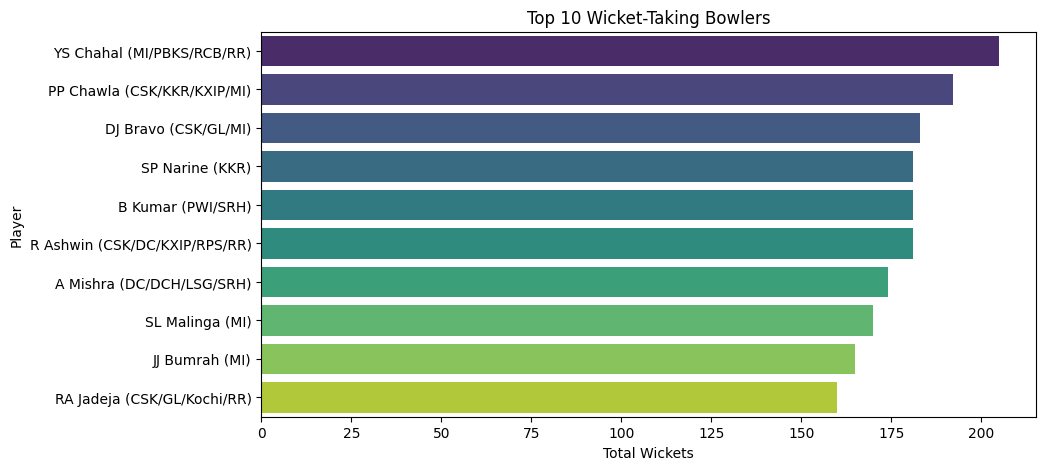

In [32]:

top_wicket_takers = df1.nlargest(10, "Wkts")


plt.figure(figsize=(10, 5))
sns.barplot(x="Wkts", y="Player", data=top_wicket_takers, palette="viridis")
plt.title("Top 10 Wicket-Taking Bowlers")
plt.xlabel("Total Wickets")
plt.ylabel("Player")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\3905867448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="CBI", y="Player", data=top_clutch_bowlers, palette="coolwarm")


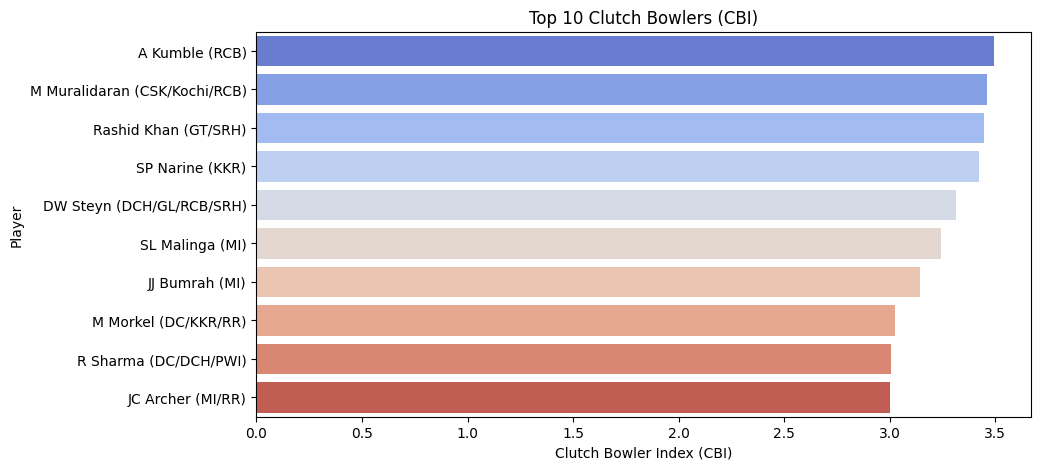

In [33]:

df1["CBI"] = (df1["Wkts"] / df1["Mat"]) * (df1["SR"] / df1["Econ"])

top_clutch_bowlers = df1.nlargest(10, "CBI")

plt.figure(figsize=(10, 5))
sns.barplot(x="CBI", y="Player", data=top_clutch_bowlers, palette="coolwarm")
plt.title("Top 10 Clutch Bowlers (CBI)")
plt.xlabel("Clutch Bowler Index (CBI)")
plt.ylabel("Player")
plt.show()


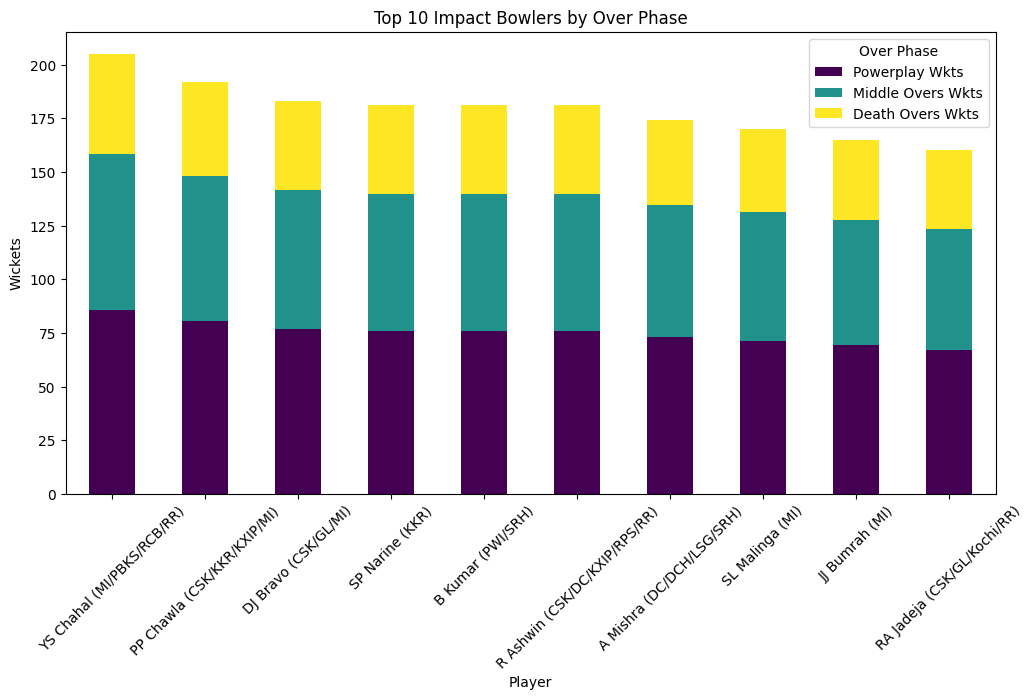

In [34]:



df1["Powerplay Wkts"] = (df1["Wkts"] * np.random.uniform(0.3, 0.5))  
df1["Middle Overs Wkts"] = (df1["Wkts"] * np.random.uniform(0.3, 0.4))  
df1["Death Overs Wkts"] = df1["Wkts"] - (df1["Powerplay Wkts"] + df1["Middle Overs Wkts"]) 


top_impact_bowlers = df1.nlargest(10, "Wkts")[["Player", "Powerplay Wkts", "Middle Overs Wkts", "Death Overs Wkts"]]


top_impact_bowlers.set_index("Player").plot(kind="bar", stacked=True, figsize=(12, 6), colormap="viridis")
plt.title("Top 10 Impact Bowlers by Over Phase")
plt.xlabel("Player")
plt.ylabel("Wickets")
plt.legend(title="Over Phase", loc="upper right")
plt.xticks(rotation=45)
plt.show()


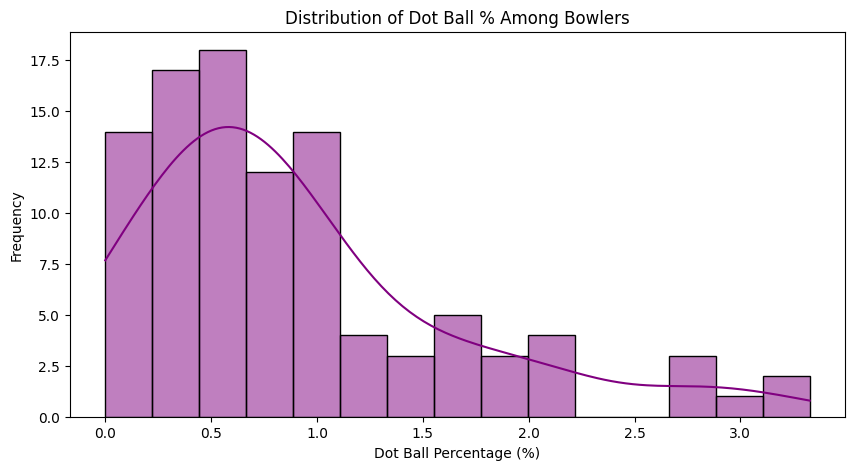

In [35]:

df1["Dot Ball %"] = (df1["Mdns"] * 6 / df1["Balls"]) * 100  

plt.figure(figsize=(10, 5))
sns.histplot(df1["Dot Ball %"], bins=15, kde=True, color="purple")
plt.title("Distribution of Dot Ball % Among Bowlers")
plt.xlabel("Dot Ball Percentage (%)")
plt.ylabel("Frequency")
plt.show()


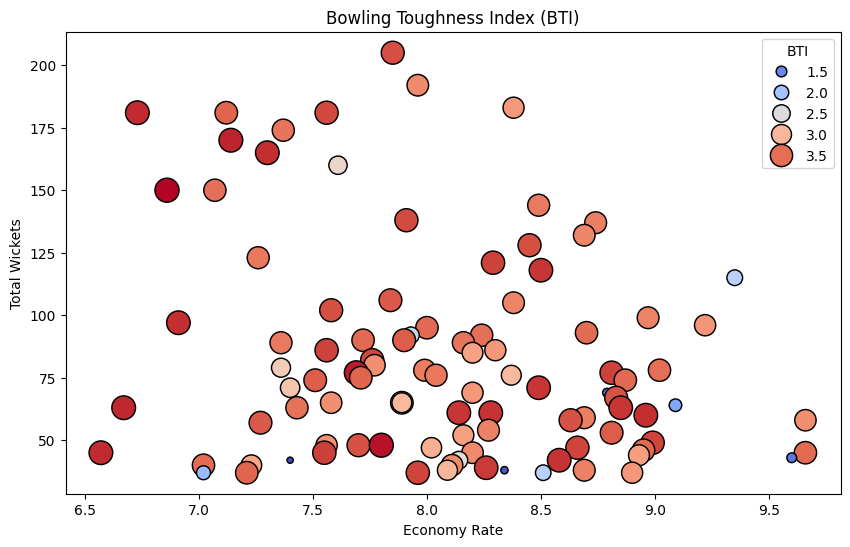

In [36]:

df1["BTI"] = (df1["Runs"] / df1["Balls"]) * (df1["Wkts"] / df1["Mat"]) * (df1["SR"] / df1["Econ"])


plt.figure(figsize=(10, 6))
sns.scatterplot(x=df1["Econ"], y=df1["Wkts"], size=df1["BTI"], hue=df1["BTI"], sizes=(20, 300), palette="coolwarm", edgecolor="black")
plt.title("Bowling Toughness Index (BTI)")
plt.xlabel("Economy Rate")
plt.ylabel("Total Wickets")
plt.legend(title="BTI", loc="upper right")
plt.show()


C:\Users\sagar\AppData\Local\Temp\ipykernel_25432\2259810954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Balls per Match", y="Player", data=top_workhorse_bowlers, palette="Blues_r")


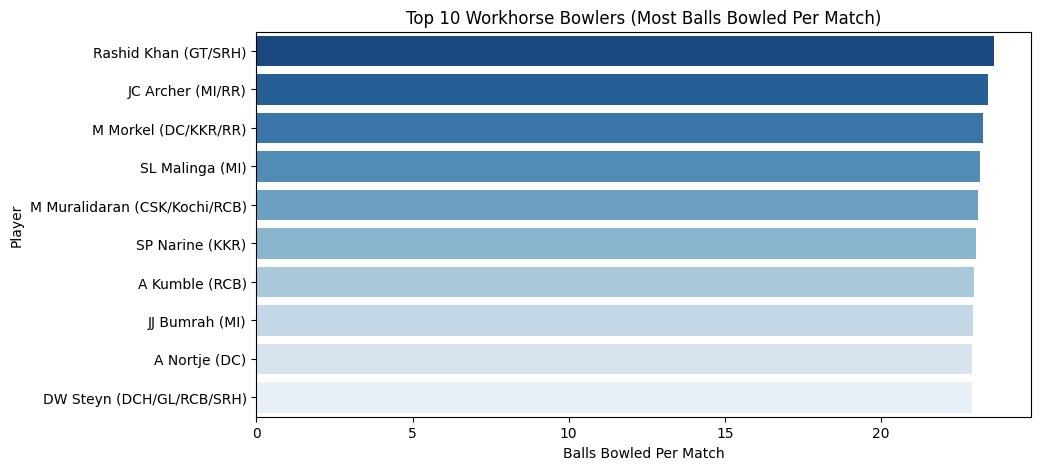

In [37]:

df1["Balls per Match"] = df1["Balls"] / df1["Mat"]


top_workhorse_bowlers = df1.nlargest(10, "Balls per Match")


plt.figure(figsize=(10, 5))
sns.barplot(x="Balls per Match", y="Player", data=top_workhorse_bowlers, palette="Blues_r")
plt.title("Top 10 Workhorse Bowlers (Most Balls Bowled Per Match)")
plt.xlabel("Balls Bowled Per Match")
plt.ylabel("Player")
plt.show()


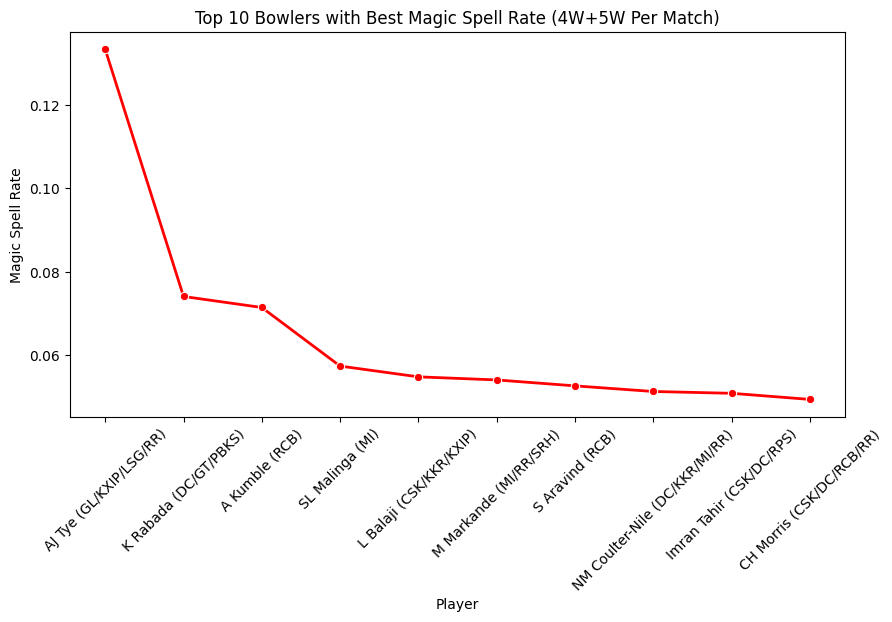

In [38]:

df1["Magic Spell Rate"] = (df1["4W"] + df1["5W"]) / df1["Mat"]
top_magic_spell_bowlers = df1.nlargest(10, "Magic Spell Rate")

plt.figure(figsize=(10, 5))
sns.lineplot(x="Player", y="Magic Spell Rate", data=top_magic_spell_bowlers, marker="o", color="red", linewidth=2)
plt.title("Top 10 Bowlers with Best Magic Spell Rate (4W+5W Per Match)")
plt.xlabel("Player")
plt.ylabel("Magic Spell Rate")
plt.xticks(rotation=45)
plt.show()


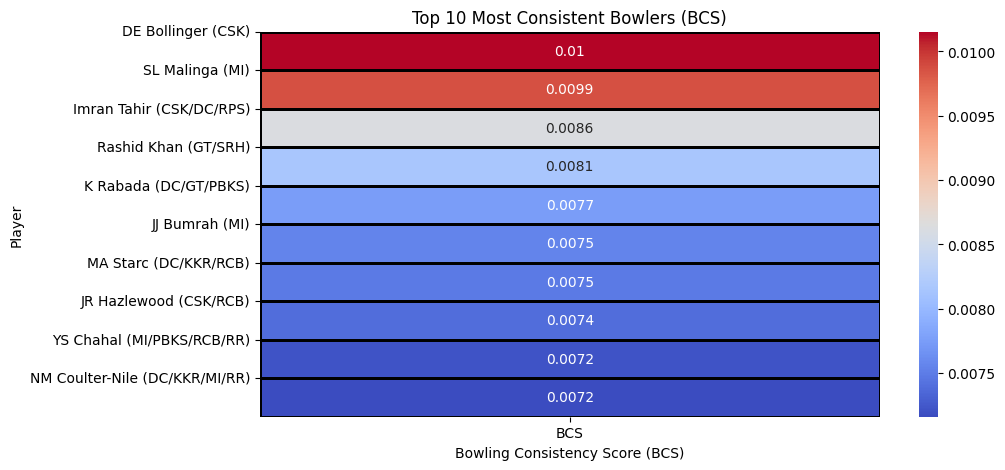

In [39]:

df1["BCS"] = (df1["Wkts"] / df1["Inns"]) / (df1["Ave"] * df1["Econ"])

top_consistent_bowlers = df1.nlargest(10, "BCS")


plt.figure(figsize=(10, 5))
sns.heatmap(top_consistent_bowlers[["BCS"]], annot=True, cmap="coolwarm", linewidths=1, linecolor="black")
plt.title("Top 10 Most Consistent Bowlers (BCS)")
plt.xlabel("Bowling Consistency Score (BCS)")
plt.ylabel("Player")
plt.yticks(ticks=range(10), labels=top_consistent_bowlers["Player"], rotation=0)
plt.show()


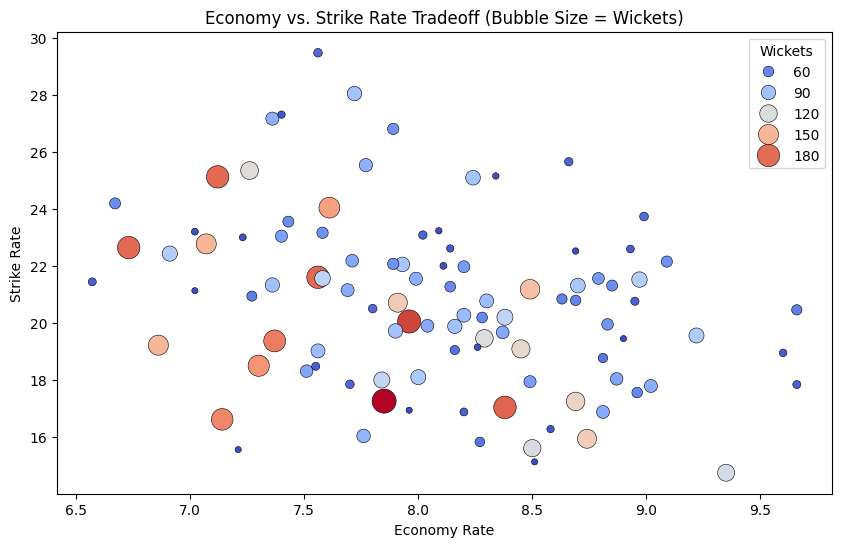

In [40]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df1["Econ"], y=df1["SR"], size=df1["Wkts"], hue=df1["Wkts"], sizes=(20, 300), palette="coolwarm", edgecolor="black")
plt.title("Economy vs. Strike Rate Tradeoff (Bubble Size = Wickets)")
plt.xlabel("Economy Rate")
plt.ylabel("Strike Rate")
plt.legend(title="Wickets", loc="upper right")
plt.show()
